In [1]:
import pandas as pd
import sys
import os
import numpy as np

# Get the parent directory of the notebooks folder
notebook_dir = os.path.dirname(os.path.abspath('__file__'))
parent_dir = os.path.dirname(notebook_dir)
sys.path.insert(0, parent_dir)

In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, mutual_info_classif
import matplotlib.pyplot as plt

In [12]:
# Load dataset (already encoded)
df = pd.read_csv('../data/processed_data/cybersecurity_attacks_dataset1_finalfeatures.csv')

In [13]:
df.head(10)

,Attack Type,Severity Level,Packet Length_Quartile,Anomaly Scores_Quartile,Packet Type_Data,Malware Indicators_1,Alerts/Warnings_1,Attack Signature_Known Pattern B,Firewall Logs_1,IDS/IPS Alerts_1,...,Browser_family_Opera,Browser_family_Other,Browser_family_Safari,OS_family_Linux,OS_family_Mac OS X,OS_family_Windows,OS_family_iOS,Device_type_PC,Device_type_Tablet,Device_type_Unknown
0,3,0,1,1,True,True,False,True,True,False,...,False,False,False,False,False,True,False,True,False,False
1,3,0,3,2,True,True,False,False,True,False,...,False,False,False,False,False,True,False,True,False,False
2,1,0,0,3,False,True,True,True,True,True,...,False,False,False,False,False,True,False,True,False,False
3,3,1,0,0,True,False,True,True,False,True,...,False,False,False,False,True,False,False,True,False,False
4,1,0,3,0,True,False,True,True,False,True,...,False,False,False,False,False,True,False,True,False,False
5,3,1,3,0,True,False,False,False,False,False,...,True,False,False,True,False,False,False,True,False,False
6,1,2,0,1,True,False,False,True,True,False,...,True,False,False,True,False,False,False,True,False,False
7,2,2,2,2,True,True,True,False,True,True,...,False,False,False,False,True,False,False,True,False,False
8,2,2,3,2,False,True,True,False,True,True,...,False,False,False,False,True,False,False,True,False,False
9,3,1,0,0,True,False,True,True,False,False,...,False,False,True,False,False,True,False,True,False,False


In [14]:
df.isna().sum()

Attack Type                                0
Severity Level                             0
Packet Length_Quartile                     0
Anomaly Scores_Quartile                    0
Packet Type_Data                           0
Malware Indicators_1                       0
Alerts/Warnings_1                          0
Attack Signature_Known Pattern B           0
Firewall Logs_1                            0
IDS/IPS Alerts_1                           0
Log Source_Server                          0
is_weekend_1                               0
Protocol_TCP                               0
Protocol_UDP                               0
Traffic Type_FTP                           0
Traffic Type_HTTP                          0
Action Taken_Ignored                       0
Action Taken_Logged                        0
Network Segment_Segment B                  0
Network Segment_Segment C                  0
hours_div_6-20                             0
ContinentName_Source_Europe                0
ContinentN

In [15]:
df.nunique()

Attack Type                                3
Severity Level                             3
Packet Length_Quartile                     4
Anomaly Scores_Quartile                    4
Packet Type_Data                           2
Malware Indicators_1                       2
Alerts/Warnings_1                          2
Attack Signature_Known Pattern B           2
Firewall Logs_1                            2
IDS/IPS Alerts_1                           2
Log Source_Server                          2
is_weekend_1                               2
Protocol_TCP                               2
Protocol_UDP                               2
Traffic Type_FTP                           2
Traffic Type_HTTP                          2
Action Taken_Ignored                       2
Action Taken_Logged                        2
Network Segment_Segment B                  2
Network Segment_Segment C                  2
hours_div_6-20                             2
ContinentName_Source_Europe                2
ContinentN

In [16]:
# Separate features and target
X = df.drop('Attack Type', axis=1)
y = df['Attack Type']

In [19]:
X.shape, df.shape

((40000, 50), (40000, 51))

In [20]:
df.columns

Index(['Attack Type', 'Severity Level', 'Packet Length_Quartile',
       'Anomaly Scores_Quartile', 'Packet Type_Data', 'Malware Indicators_1',
       'Alerts/Warnings_1', 'Attack Signature_Known Pattern B',
       'Firewall Logs_1', 'IDS/IPS Alerts_1', 'Log Source_Server',
       'is_weekend_1', 'Protocol_TCP', 'Protocol_UDP', 'Traffic Type_FTP',
       'Traffic Type_HTTP', 'Action Taken_Ignored', 'Action Taken_Logged',
       'Network Segment_Segment B', 'Network Segment_Segment C',
       'hours_div_6-20', 'ContinentName_Source_Europe',
       'ContinentName_Source_North America', 'ContinentName_Source_Other',
       'ContinentName_Destination_Europe',
       'ContinentName_Destination_North America',
       'ContinentName_Destination_Other', 'ContinentName_Proxy_North America',
       'ContinentName_Proxy_Other', 'ContinentName_Proxy_noProxy',
       'Source IP_Class_B', 'Source IP_Class_C', 'Destination IP_Class_B',
       'Destination IP_Class_C', 'Proxy_Class_B', 'Proxy_Class_C'

In [21]:
df.isna().sum()

Attack Type                                0
Severity Level                             0
Packet Length_Quartile                     0
Anomaly Scores_Quartile                    0
Packet Type_Data                           0
Malware Indicators_1                       0
Alerts/Warnings_1                          0
Attack Signature_Known Pattern B           0
Firewall Logs_1                            0
IDS/IPS Alerts_1                           0
Log Source_Server                          0
is_weekend_1                               0
Protocol_TCP                               0
Protocol_UDP                               0
Traffic Type_FTP                           0
Traffic Type_HTTP                          0
Action Taken_Ignored                       0
Action Taken_Logged                        0
Network Segment_Segment B                  0
Network Segment_Segment C                  0
hours_div_6-20                             0
ContinentName_Source_Europe                0
ContinentN

In [22]:
# 1. Check feature importance with Random Forest
rf_temp = RandomForestClassifier(n_estimators=100, random_state=0)
rf_temp.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

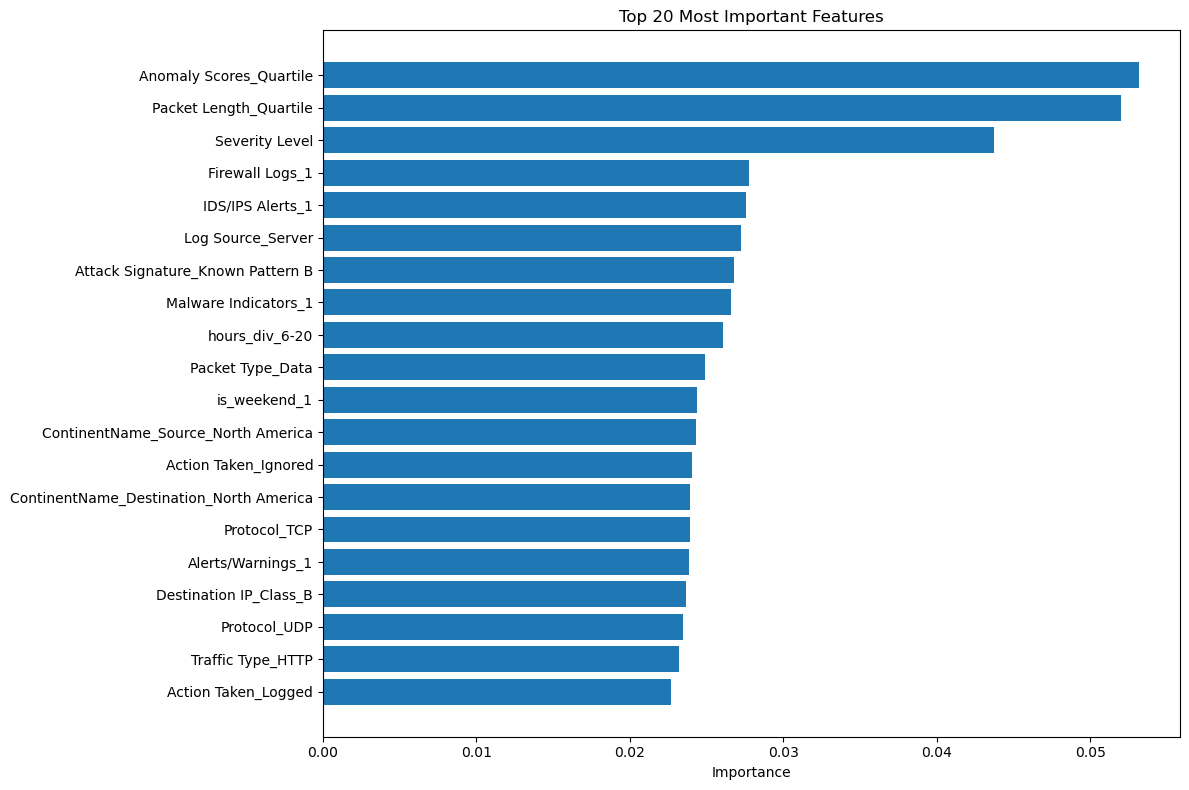

Top 10 Most Important Features:
                                    feature  importance
2                   Anomaly Scores_Quartile    0.053173
1                    Packet Length_Quartile    0.051959
0                            Severity Level    0.043716
7                           Firewall Logs_1    0.027724
8                          IDS/IPS Alerts_1    0.027539
9                         Log Source_Server    0.027202
6          Attack Signature_Known Pattern B    0.026772
4                      Malware Indicators_1    0.026568
19                           hours_div_6-20    0.026049
3                          Packet Type_Data    0.024903
10                             is_weekend_1    0.024342
21       ContinentName_Source_North America    0.024299
15                     Action Taken_Ignored    0.024036
24  ContinentName_Destination_North America    0.023910
11                             Protocol_TCP    0.023901
5                         Alerts/Warnings_1    0.023820
31              

In [23]:
# Plot feature importances
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_temp.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 8))
plt.barh(feature_importance['feature'][:20], feature_importance['importance'][:20])
plt.xlabel('Importance')
plt.title('Top 20 Most Important Features')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../data/results/feature_importance.png')
plt.show()

print("Top 10 Most Important Features:")
print(feature_importance.head(20))
print('='*70)
print('Importance of all features:')
print(feature_importance)

In [24]:
# 2. Use Mutual Information to identify features with predictive power
mi_scores = mutual_info_classif(X, y, random_state=0)
mi_df = pd.DataFrame({
    'feature': X.columns,
    'mi_score': mi_scores
}).sort_values('mi_score', ascending=False)

print("\nTop 10 Features by Mutual Information:")
print(mi_df.head(10))


Top 10 Features by Mutual Information:
                        feature  mi_score
33                Proxy_Class_B  0.006464
11                 Protocol_TCP  0.006365
47               Device_type_PC  0.006355
49          Device_type_Unknown  0.005183
27    ContinentName_Proxy_Other  0.005171
2       Anomaly Scores_Quartile  0.004752
7               Firewall Logs_1  0.004749
16          Action Taken_Logged  0.004516
28  ContinentName_Proxy_noProxy  0.003895
32       Destination IP_Class_C  0.003568


In [ ]:
# 3. Create interaction features for top features
# top_features = feature_importance['feature'][:10].tolist()
# print(top_features)

['Anomaly Scores_Quartile', 'Packet Length_Quartile', 'Severity Level', 'Log Source_Server', 'hours_div_6-20', 'Attack Signature_Known Pattern B', 'ContinentName_Source_North America', 'is_weekend_1', 'ContinentName_Destination_North America', 'Packet Type_Data']


In [ ]:
# Example: Create interaction between top 2 features
# df[f'{top_features[0]}_x_{top_features[1]}'] = df[top_features[0]] * df[top_features[1]]

In [25]:
# Identify low-importance features to potentially drop
low_importance_threshold = 0.01 # should we adjust?
low_importance_features = feature_importance[feature_importance['importance'] < low_importance_threshold]
print(f"\n{len(low_importance_features)} features with importance < {low_importance_threshold}")
print("Consider dropping these features to simplify the model.")
if not low_importance_features.empty:
    print("Low-importance features:")
    print(low_importance_features['feature'].tolist())
else:
    print("No features below the threshold.")


6 features with importance < 0.01
Consider dropping these features to simplify the model.
Low-importance features:
['OS_family_Mac OS X', 'Proxy_Class_C', 'Device_type_Unknown', 'OS_family_iOS', 'Browser_family_Other', 'Device_type_Tablet']
